In [29]:
import json
import random
import re
from collections import Counter, defaultdict
from pathlib import Path
import numpy as np
import pandas as pd

### Load Path

In [30]:
path = Path('../datasets/Entity Recognition in Resumes.json')

Entity_labels = [
    'Name',
    'Designation',
    'Companies worked at', 
    'Location',
    'Email Address', 
    'College Name', 
    'Degree', 
    'Graduation Year',
    'Skills', 
    'Years of Experience'
]

Non_lemma_label ={
    'Name', 
    'Email Address', 
    'Graduation Year', 
    'Location',
    'College Name', 
    'Companies worked at'
}

print(f"Entity types: {len(Entity_labels)}")

Entity types: 10


### Data Parsing

In [31]:
def load_jsonl(path: Path) -> list[dict]:
    """Load all records from a JSONL file."""
    records = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records


def parse_record(record: dict) -> tuple[str, list[tuple]]:
    """
    Extract (content, spans) from a single record.

    Returns
    -------
    content : str
        Raw resume text.
    spans : list of (start, end, label)
        Character-level offsets where end is EXCLUSIVE (Python slice convention).
        Sorted by start position. UNKNOWN labels are dropped.
    """
    content = record['content']
    spans = []
    for ann in record.get('annotation', []):
        label = ann['label'][0] if ann['label'] else 'UNKNOWN'
        if label == 'UNKNOWN':
            continue
        for pt in ann['points']:
            start = pt['start']
            end = pt['end'] + 1   # convert inclusive -> exclusive
            # Sanity check: stored text must match the slice
            if content[start:end] != pt['text']:
                continue
            spans.append((start, end, label))

    # Sort by start; resolve any end ties by longest span first
    spans.sort(key=lambda s: (s[0], -s[1]))
    return content, spans


# Load & parse all records
raw_records = load_jsonl(path)
parsed = [parse_record(r) for r in raw_records]

print(f"Records loaded  : {len(parsed)}")
print(f"Total spans     : {sum(len(s) for _, s in parsed)}")
print()

# Inspect first record
content0, spans0 = parsed[0]
print(f"=== Resume 0 (first 200 chars) ===")
print(content0[:200])
print(f"\n=== Spans (first 10) ===")
for start, end, label in spans0[:10]:
    print(f"  [{start:5d}:{end:5d}]  {label:<25}  '{content0[start:end][:60]!s}'")

Records loaded  : 220
Total spans     : 3333

=== Resume 0 (first 200 chars) ===
Abhishek Jha
Application Development Associate - Accenture

Bengaluru, Karnataka - Email me on Indeed: indeed.com/r/Abhishek-Jha/10e7a8cb732bc43a

• To work for an organization which provides me the o

=== Spans (first 10) ===
  [    0:   12]  Name                       'Abhishek Jha'
  [   13:   46]  Designation                'Application Development Associate'
  [   49:   58]  Companies worked at        'Accenture'
  [   60:   69]  Location                   'Bengaluru'
  [   95:  146]  Email Address              'Indeed: indeed.com/r/Abhishek-Jha/10e7a8cb732bc43a
'
  [  372:  405]  Designation                'Application Development Associate'
  [  407:  416]  Companies worked at        'Accenture'
  [  727:  770]  Designation                'B.E in Information science and engineering
'
  [  771:  814]  College Name               'B.v.b college of engineering and technology'
  [  856:  861]  Graduation

### Tokenization & BIO Tagging

World level tokenization (CRF/HMM/BiLSTM)

In [32]:
# Word-level tokenizer

def word_tokenize(text: str) -> list[tuple[str, int, int]]:
    """
    Split text on whitespace, preserving character positions.

    Returns
    -------
    list of (token_str, start, end)  where end is exclusive.
    """
    return [(m.group(), m.start(), m.end())
            for m in re.finditer(r'\S+', text)]


def assign_bio_word(tokens: list[tuple], spans: list[tuple]) -> list[tuple[str, str]]:
    """
    Assign BIO tags to word-level tokens using character-offset spans.

    Strategy
    --------
    For each token, find the first span that fully contains it
    (token_start >= span_start AND token_end <= span_end).
    The tag is B- if no prior token in the same span exists, else I-.
    """
    # Build a fast lookup: character position -> (span_index, label)
    # We iterate spans in order and mark the first token of each span.
    span_first_token: dict[int, bool] = {}   # span_idx -> first-token-seen flag

    tagged = []
    for tok, t_start, t_end in tokens:
        label_tag = 'O'
        for span_idx, (s_start, s_end, label) in enumerate(spans):
            if t_start >= s_start and t_end <= s_end:
                if span_idx not in span_first_token:
                    span_first_token[span_idx] = True
                    label_tag = f'B-{label}'
                else:
                    label_tag = f'I-{label}'
                break
        tagged.append((tok, label_tag))
    return tagged


def word_level_bio(content: str, spans: list[tuple]) -> list[tuple[str, str]]:
    """End-to-end word-level BIO tagging for one resume."""
    tokens = word_tokenize(content)
    return assign_bio_word(tokens, spans)


# Demo: resume 0 
bio_word0 = word_level_bio(content0, spans0)

print(f"{'Token':<40} {'BIO Tag'}")
print("-" * 60)
for tok, tag in bio_word0[:25]:
    print(f"{tok:<40} {tag}")

Token                                    BIO Tag
------------------------------------------------------------
Abhishek                                 B-Name
Jha                                      I-Name
Application                              B-Designation
Development                              I-Designation
Associate                                I-Designation
-                                        O
Accenture                                B-Companies worked at
Bengaluru,                               O
Karnataka                                O
-                                        O
Email                                    O
me                                       O
on                                       O
Indeed:                                  B-Email Address
indeed.com/r/Abhishek-Jha/10e7a8cb732bc43a I-Email Address
•                                        O
To                                       O
work                                     O
for                 

In [33]:
# BIO tag statistics across full dataset
all_bio_word = [word_level_bio(c, s) for c, s in parsed]
tag_counter = Counter(tag for seq in all_bio_word for _, tag in seq)

# Group by label
label_token_counts = defaultdict(lambda: {'B': 0, 'I': 0})
for tag, cnt in tag_counter.items():
    if tag == 'O':
        continue
    prefix, label = tag.split('-', 1)
    label_token_counts[label][prefix] += cnt

summary = pd.DataFrame([
    {'Label': lbl, 
     'B tokens': v['B'], 
     'I tokens': v['I'], 
     'Total tokens': v['B'] + v['I'],
     'Avg tokens/entity': round((v['B'] + v['I']) / v['B'], 2) if v['B'] else 0} for lbl, v in label_token_counts.items()
]).sort_values('Total tokens', ascending=False).reset_index(drop=True)

total_O = tag_counter.get('O', 0)
total_entity = sum(summary['Total tokens'])
total_all = total_O + total_entity

print(f"Total tokens in dataset : {total_all:,}")
print(f"O (outside entity)      : {total_O:,}  ({100*total_O/total_all:.1f}%)")
print(f"Entity tokens           : {total_entity:,}  ({100*total_entity/total_all:.1f}%)")
print()
summary

Total tokens in dataset : 113,925
O (outside entity)      : 102,292  (89.8%)
Entity tokens           : 11,633  (10.2%)



,Label,B tokens,I tokens,Total tokens,Avg tokens/entity
0,Skills,349,5974,6323,18.12
1,Designation,478,793,1271,2.66
2,College Name,286,749,1035,3.62
3,Companies worked at,596,367,963,1.62
4,Degree,257,675,932,3.63
5,Name,223,234,457,2.05
6,Email Address,189,75,264,1.40
7,Graduation Year,225,0,225,1.00
8,Location,82,4,86,1.05
9,Years of Experience,40,37,77,1.93


Sub-Word Tokenization (BERT/DistilBERT)

In [34]:
# Sub-word tokenizer (WordPiece simulation)
# In production replace `wordpiece_tokenize` with:
#   from transformers import AutoTokenizer
#   tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

# Common resume vocabulary for the demo splitter
_VOCAB = {
    'software','engineer','engineering','development','application','management','system','data','science','machine','learning','computer','network','database','java','python','java','javascript','design','product','project','team','work','experience','university','college','bachelor','master','information','technology','associate','senior','lead','manager','analyst','developer','architect','director','india','bengal','karnat','mumbai','delhi','hydera','pune','chennai','kolkata','indeed','email','skills','profile','education','company','accenture','infosys','wipro','tata','consultancy','services','limited','private','solutions','global','research','artificial','intelligence','deep','neural','cloud','security','mobile','web','front','back','full','stack','agile','scrum','testing','quality','assurance'
}

def wordpiece_tokenize(word: str, vocab: set = _VOCAB) -> list[str]:
    """
    Greedy left-to-right WordPiece tokenizer (demo approximation).
    Tries to match the longest prefix in vocab, marks remainder with ##.
    In production, replace with HuggingFace tokenizer.
    """
    lower = word.lower()
    if lower in vocab or len(lower) <= 3:
        return [lower]
    # Try longest prefix in vocab
    for split in range(min(len(lower) - 2, 12), 3, -1):
        prefix = lower[:split]
        if prefix in vocab:
            suffix = lower[split:]
            return [prefix, f"##{suffix}"]
    return [lower]     # fall back: keep as single token


def align_bio_subword(word_bio: list[tuple[str, str]]) -> list[tuple[str, str]]:
    """
    Expand word-level BIO tags to sub-word BIO tags.

    Rules
    -----
    - B-X word  → first sub-token gets B-X, rest get I-X
    - I-X word  → all sub-tokens get I-X
    - O   word  → all sub-tokens get O
    """
    result = []
    for word, word_tag in word_bio:
        sub_tokens = wordpiece_tokenize(word)
        for i, sub in enumerate(sub_tokens):
            if word_tag == 'O':
                result.append((sub, 'O'))
            elif word_tag.startswith('B-'):
                label = word_tag[2:]
                result.append((sub, f"B-{label}" if i == 0 else f"I-{label}"))
            else:   # I-X
                result.append((sub, word_tag))
    return result


def subword_bio(content: str, spans: list[tuple]) -> list[tuple[str, str]]:
    """Full sub-word BIO pipeline for one resume."""
    word_bio = word_level_bio(content, spans)
    return align_bio_subword(word_bio)


# Demo
bio_sub0 = subword_bio(content0, spans0)

print(f"Word tokens  : {len(bio_word0)}")
print(f"Sub-word tokens: {len(bio_sub0)}")
print()
print(f"{'Sub-token':<30} {'BIO Tag'}")
print("-" * 50)
for tok, tag in bio_sub0[:30]:
    print(f'{tok:<30} {tag}')

Word tokens  : 227
Sub-word tokens: 237

Sub-token                      BIO Tag
--------------------------------------------------
abhishek                       B-Name
jha                            I-Name
application                    B-Designation
development                    I-Designation
associate                      I-Designation
-                              O
accenture                      B-Companies worked at
bengal                         O
##uru,                         O
karnat                         O
##aka                          O
-                              O
email                          O
me                             O
on                             O
indeed:                        B-Email Address
indeed                         I-Email Address
##.com/r/abhishek-jha/10e7a8cb732bc43a I-Email Address
•                              O
to                             O
work                           O
for                            O
an                         

In [35]:
# Compare word-level vs sub-word on a multi-word entity
sample_pairs = [
    ('Software',     'B-Skills'),
    ('Engineering',  'I-Skills'),
    ('and',          'O'),
    ('Development',  'I-Skills'),
    ('at',           'O'),
    ('Bangalore',    'B-Location'),
]

sub_expanded = align_bio_subword(sample_pairs)

print("=== Word-level BIO ===")
print(f"{'Token':<25} {'Tag'}")
for tok, tag in sample_pairs:
    print(f"{tok:<25} {tag}")

print()
print("=== Sub-word BIO (after WordPiece expansion) ===")
print(f"{'Sub-token':<25} {'Tag'}")
for tok, tag in sub_expanded:
    print(f"{tok:<25} {tag}")

=== Word-level BIO ===
Token                     Tag
Software                  B-Skills
Engineering               I-Skills
and                       O
Development               I-Skills
at                        O
Bangalore                 B-Location

=== Sub-word BIO (after WordPiece expansion) ===
Sub-token                 Tag
software                  B-Skills
engineering               I-Skills
and                       O
development               I-Skills
at                        O
bangalore                 B-Location


### Text Normalization & Linguistic Cleaning

In [36]:
import re, unicodedata
import spacy

nlp = spacy.load("en_core_web_sm")

# Tech/identifier tokens that must NEVER be altered 
# Pattern: contains digits, +, #, dots-between-letters, or all-caps ≤ 5 chars
# Catches: C++, C#, .NET, R, F#, CSS3, ES6, HTML5, AWS, API, SQL, etc.
_TECH_TOKEN = re.compile(
    r'[+#]'                # C++, C#, F#
    r'|\d'                 # contains digit: ES6, CSS3, HTML5
    r'|\.\w'               # starts with dot: .NET, .js
    r'|^[A-Z]{1,5}$'       # all-caps acronym: AWS, SQL, API, R, GO
    r'|^\.[a-z]+'          # file extension / framework: .py, .js
)

def is_tech_token(token: str) -> bool:
    """True for programming languages, frameworks, acronyms — keep as-is."""
    return bool(_TECH_TOKEN.search(token))


# Unicode normalisation
def to_ascii(text: str) -> str:
    return unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('ascii')

def case_fold(token: str) -> str:
    return to_ascii(token).lower()

def remove_edge_noise(token: str) -> str:
    """Strip leading/trailing punctuation. Keeps ## for sub-word tokens."""
    if token.startswith('##'):
        inner = re.sub(r'^[^\w#]+|[^\w]+$', '', token[2:])
        return '##' + inner
    return re.sub(r'^[^\w.#+]+|[^\w.#+]+$', '', token)
    #                         ^^^^^ preserve . + # inside tech tokens

# Tokens that are pure noise
_NOISE_PATTERN = re.compile(
    r'^[^\w.#+]+$'       # no alphanumeric / tech chars at all
    r'|^[\-–—]+$'        # only dashes
    r'|^[•·▪●■◦○]+$'     # bullets
)

def is_noise_token(token: str) -> bool:
    return bool(_NOISE_PATTERN.match(token)) or len(token.strip()) == 0


# spaCy lemmatizer 

def lemmatize(token: str) -> str:
    """
    Lemmatize using spaCy's en_core_web_sm model.

    Tech tokens (C++, .NET, AWS, HTML5 …) are returned unchanged.
    Hyphened compounds are lemmatized as a whole (spaCy handles them).
    """
    if is_tech_token(token):
        return token                          # <- fix: C++ stays C++

    doc = nlp(token)
    return doc[0].lemma_ if doc else token    # lemma of first token


# Combined normalization step

def normalize_token(
    token: str,
    bio_tag: str,
    apply_lemma: bool = True
) -> str | None:
    """
    Full normalization pipeline for a single token.
    Returns None if the token should be dropped (noise).
    """
    # 1. Preserve original casing for tech-token check BEFORE folding
    is_tech = is_tech_token(token)

    # 2. Case fold (lowercase + ASCII)
    token = case_fold(token)

    # 3. Strip edge punctuation
    token = remove_edge_noise(token)

    # 4. Drop noise tokens
    if is_noise_token(token):
        return None

    # 5. Lemmatize, skip if: tech token, identifier label, or too short
    if apply_lemma and not is_tech and len(token) > 2:
        token = lemmatize(token)

    return token if token else None


def normalize_sequence(
    bio_tokens: list[tuple[str, str]],
    no_lemma_labels: set = Non_lemma_label
) -> list[tuple[str, str]]:
    """
    Normalize an entire BIO-tagged sequence.
    - Identifier labels skip lemmatization (proper nouns, emails, dates).
    - Pure noise tokens are removed.
    - Tech tokens (C++, AWS, .NET …) are never lemmatized.
    """
    result = []
    for token, tag in bio_tokens:
        label = tag.split('-', 1)[1] if '-' in tag else None
        apply_lemma = (label not in no_lemma_labels)
        normalized = normalize_token(token, tag, apply_lemma=apply_lemma)
        if normalized is not None:
            result.append((normalized, tag))
    return result

test_words = [
    'developing', 'technologies', 'responsibilities', 'Engineers',
    'Organizations', 'implementations', 'managed', 'applications',
    'processing', 'architectures', 'collaborations', 'specializations',
    'C++', 'C#', '.NET', 'AWS', 'HTML5', '•', '--', 'python', 'skills'
]

print(f"{'Original':<25} {'Normalized':<25} {'Lemmatized'}")
print("=" * 65)
for w in test_words:
    is_tech = is_tech_token(w)          # check BEFORE case folding
    folded = case_fold(w)
    cleaned = remove_edge_noise(folded)

    if is_noise_token(cleaned):
        print(f"{w:<25} {cleaned or '(empty)':<25} [NOISE — dropped]")
    elif is_tech:
        print(f"{w:<25} {cleaned:<25} {cleaned}  <- tech token (unchanged)")
    else:
        lem = lemmatize(cleaned)         # spaCy lemmatizer
        print(f"{w:<25} {cleaned:<25} {lem}")


Original                  Normalized                Lemmatized
developing                developing                develop
technologies              technologies              technology
responsibilities          responsibilities          responsibility
Engineers                 engineers                 engineer
Organizations             organizations             organization
implementations           implementations           implementation
managed                   managed                   manage
applications              applications              application
processing                processing                process
architectures             architectures             architecture
collaborations            collaborations            collaboration
specializations           specializations           specialization
C++                       c++                       c++  <- tech token (unchanged)
C#                        c#                        c#  <- tech token (unchanged)
.NET    

In [37]:
# Apply full normalization to resume 0 (word-level) 
norm_bio0 = normalize_sequence(bio_word0)

print(f"Tokens before normalization : {len(bio_word0)}")
print(f"Tokens after  normalization : {len(norm_bio0)}")
print(f"Tokens removed (noise)      : {len(bio_word0) - len(norm_bio0)}")
print()
print(f"{'Normalized Token':<40} {'BIO Tag'}")
print("=" * 60)
for tok, tag in norm_bio0[:25]:
    print(f"{tok:<40} {tag}")

Tokens before normalization : 227
Tokens after  normalization : 210
Tokens removed (noise)      : 17

Normalized Token                         BIO Tag
abhishek                                 B-Name
jha                                      I-Name
application                              B-Designation
development                              I-Designation
associate                                I-Designation
accenture                                B-Companies worked at
bengaluru                                O
karnataka                                O
email                                    O
me                                       O
on                                       O
indeed                                   B-Email Address
indeed.com/r/abhishek-jha/10e7a8cb732bc43a I-Email Address
to                                       O
work                                     O
for                                      O
an                                       O
organization          

In [38]:
# Side-by-side: raw vs normalized for entity tokens only
raw_entity   = [(t, g) for t, g in bio_word0   if g != 'O']
norm_entity  = [(t, g) for t, g in norm_bio0   if g != 'O']

# Align on tag for display (zip won't work if noise tokens are dropped)
# Instead, rebuild a aligned view
raw_map  = {i: (t, g) for i, (t, g) in enumerate(bio_word0)  if g != 'O'}
norm_map = {}
j = 0
for i, (t, g) in enumerate(bio_word0):
    if g != 'O':
        # find corresponding normalized token
        while j < len(norm_bio0) and norm_bio0[j][1] == 'O':
            j += 1
        if j < len(norm_bio0):
            norm_map[i] = norm_bio0[j]
            j += 1

print(f"{'Raw Token':<30} {'Normalized Token':<30} {'Tag'}")
print("=" * 80)
for i, (raw_t, raw_g) in list(raw_map.items())[:20]:
    norm_t = norm_map.get(i, ('(dropped)', raw_g))[0]
    changed = '<- changed' if raw_t.lower() != norm_t else ''
    print(f"{raw_t:<30} {norm_t:<30} {raw_g}  {changed}")

Raw Token                      Normalized Token               Tag
Abhishek                       abhishek                       B-Name  
Jha                            jha                            I-Name  
Application                    application                    B-Designation  
Development                    development                    I-Designation  
Associate                      associate                      I-Designation  
Accenture                      accenture                      B-Companies worked at  
Indeed:                        indeed                         B-Email Address  <- changed
indeed.com/r/Abhishek-Jha/10e7a8cb732bc43a indeed.com/r/abhishek-jha/10e7a8cb732bc43a I-Email Address  
Application                    application                    B-Designation  
Development                    development                    I-Designation  
Associate                      associate                      I-Designation  
Accenture                      accenture    

### Combine Preprocessing Pipeline

In [39]:
def preprocess_record(
    record: dict,
    subword: bool = False
) -> dict:
    """
    Full preprocessing pipeline for a single resume record.

    Parameters
    ----------
    record  : raw JSON record (content + annotation)
    subword : if True, also run sub-word BIO alignment

    Returns
    -------
    dict with keys:
        'content'        : original text
        'spans'          : parsed (start, end, label) tuples
        'word_bio_raw'   : word-level BIO before normalization
        'word_bio_norm'  : word-level BIO after normalization  <- for CRF/HMM/BiLSTM
        'sub_bio_raw'    : sub-word BIO before normalization   (if subword=True)
        'sub_bio_norm'   : sub-word BIO after normalization    <- for BERT/DistilBERT
    """
    #Parse
    content, spans = parse_record(record)

    #Word-level BIO
    word_bio_raw = word_level_bio(content, spans)

    # Normalize (word-level)
    word_bio_norm = normalize_sequence(word_bio_raw)

    result = {
        'content'       : content,
        'spans'         : spans,
        'word_bio_raw'  : word_bio_raw,
        'word_bio_norm' : word_bio_norm,
    }

    if subword:
        # Sub-word BIO
        sub_bio_raw = align_bio_subword(word_bio_raw)
        # Normalize (sub-word)
        sub_bio_norm = normalize_sequence(sub_bio_raw)
        result['sub_bio_raw']  = sub_bio_raw
        result['sub_bio_norm'] = sub_bio_norm

    return result


# Process entire dataset
processed = [preprocess_record(r, subword=True) for r in raw_records]

# Quick sanity check 
p = processed[0]
print(f"\nResume 0 token counts:")
print(f"word_bio_raw   : {len(p['word_bio_raw']):,} tokens")
print(f"word_bio_norm  : {len(p['word_bio_norm']):,} tokens  (after noise removal)")
print(f"sub_bio_raw    : {len(p['sub_bio_raw']):,} tokens")
print(f"sub_bio_norm   : {len(p['sub_bio_norm']):,} tokens")


Resume 0 token counts:
word_bio_raw   : 227 tokens
word_bio_norm  : 210 tokens  (after noise removal)
sub_bio_raw    : 237 tokens
sub_bio_norm   : 220 tokens


### Train / Val / Test Split

### Balance the training split

Because the raw corpus is heavily dominated by `O` labels, the model can learn to predict `O` too often. This section computes a training sampling distribution and oversamples resumes with more entity tokens, while keeping a small proportion of all-`O` resumes for coverage.

The resulting `idx_train_balanced` list is used for model training, while the original `idx_train` / `idx_val` / `idx_test` splits remain available for evaluation.


In [40]:
# ── Train / Val / Test Split ─────────────────────────────────────────────────
# PENTING: split SEBELUM build vocab supaya vocab tidak "melihat" val/test.
# Urutan yang benar: split → build vocab dari idx_train → encode semua split.

import json as _json
from pathlib import Path
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15   # train ≈ 70%

all_indices = list(range(len(processed)))

# 1. Pisah test dulu
idx_trainval, idx_test = train_test_split(
    all_indices, test_size=TEST_RATIO, random_state=RANDOM_SEED
)

# 2. Pisah val dari sisa
val_size_adjusted = VAL_RATIO / (1 - TEST_RATIO)
idx_train, idx_val = train_test_split(
    idx_trainval, test_size=val_size_adjusted, random_state=RANDOM_SEED
)

print(f"Total : {len(processed)}")
print(f"Train : {len(idx_train)}  ({100*len(idx_train)/len(processed):.0f}%)")
print(f"Val   : {len(idx_val)}   ({100*len(idx_val)/len(processed):.0f}%)")
print(f"Test  : {len(idx_test)}  ({100*len(idx_test)/len(processed):.0f}%)")

split_dir = Path('../datasets/split_data')
split_dir.mkdir(exist_ok=True)

def resume_balance_stats(records: list[dict], indices: list[int]) -> pd.DataFrame:
    rows = []
    for i in indices:
        tags = [tag for _, tag in records[i]['word_bio_norm']]
        total = len(tags)
        entity_tokens = sum(1 for tag in tags if tag != 'O')
        entity_ratio = entity_tokens / total if total else 0.0
        label_diversity = len({tag.split('-', 1)[1] for tag in tags if tag != 'O'})
        rows.append({
            'index': i,
            'total_tokens': total,
            'entity_tokens': entity_tokens,
            'entity_ratio': entity_ratio,
            'label_diversity': label_diversity,
        })
    return pd.DataFrame(rows)


def sample_train_indices(
    indices: list[int],
    records: list[dict],
    target_size: int | None = None,
    seed: int = RANDOM_SEED
) -> list[int]:
    """Oversample entity-rich resumes and de-emphasize all-O examples."""
    if target_size is None:
        target_size = len(indices)

    stats = resume_balance_stats(records, indices)
    weights = []
    for _, row in stats.iterrows():
        if row['entity_tokens'] == 0:
            weights.append(0.25)
        else:
            weights.append(1.0 + row['entity_ratio'] * 2.5 + min(row['label_diversity'], 4) * 0.2)

    rng = random.Random(seed)
    return rng.choices(indices, weights=weights, k=target_size)


# Build a balanced training index list for model training.
# The balanced list keeps the same total size, but reweights examples
# so that entity-rich resumes appear more often during training.
# Cap balanced size ke max 2x ukuran original untuk menghindari overfitting
idx_train_balanced = sample_train_indices(
    idx_train, processed,
    target_size=min(len(idx_train) * 2, 300),  # hard cap 300
)

# Save original splits plus balanced training indices for reproducibility.
with open(split_dir / 'split_indices.json', 'w') as f:
    _json.dump({
        'idx_train': idx_train,
        'idx_val': idx_val,
        'idx_test': idx_test,
        'idx_train_balanced': idx_train_balanced,
    }, f)

balance_stats = resume_balance_stats(processed, idx_train)
balance_stats_balanced = resume_balance_stats(processed, idx_train_balanced)

print(f"Saved -> {split_dir / 'split_indices.json'}")
print()
print("Training balance overview:")
print(f"  Original train size          : {len(idx_train)}")
print(f"  Balanced train size          : {len(idx_train_balanced)}")
print(f"  Original entity ratio (mean) : {balance_stats['entity_ratio'].mean():.4f}")
print(f"  Balanced entity ratio (mean) : {balance_stats_balanced['entity_ratio'].mean():.4f}")
print(f"  Original all-O resumes       : {(balance_stats['entity_tokens'] == 0).sum()}")
print(f"  Balanced all-O resumes       : {(balance_stats_balanced['entity_tokens'] == 0).sum()}")
print()
print("Top 5 resumes by entity ratio in balanced training sample:")
print(balance_stats_balanced.sort_values('entity_ratio', ascending=False).head()[[
    'index', 'entity_tokens', 'entity_ratio', 'label_diversity'
]])

Total : 220
Train : 154  (70%)
Val   : 33   (15%)
Test  : 33  (15%)
Saved -> ..\datasets\split_data\split_indices.json

Training balance overview:
  Original train size          : 154
  Balanced train size          : 300
  Original entity ratio (mean) : 0.1826
  Balanced entity ratio (mean) : 0.2125
  Original all-O resumes       : 0
  Balanced all-O resumes       : 0

Top 5 resumes by entity ratio in balanced training sample:
     index  entity_tokens  entity_ratio  label_diversity
171     84            207      0.873418                7
125    194             52      0.722222                5
72      74             87      0.625899                8
143     74             87      0.625899                8
132     74             87      0.625899                8


### Export Process Data

In [41]:
# Export 1: Word-level TSV (CoNLL format) —> CRF / HMM / BiLSTM 
# Format: one token per line, blank line between resumes
# token \t tag

conll_lines = []
for p in processed:
    for tok, tag in p['word_bio_norm']:
        conll_lines.append(f'{tok}\t{tag}')
    conll_lines.append('')   # blank line = resume boundary

with open('word_bio_conll.tsv', 'w', encoding='utf-8') as f:
    f.write('\n'.join(conll_lines))

print(f"CoNLL TSV saved -> word_bio_conll.tsv")
print(f"Lines: {len(conll_lines):,}  (including blank separators)")

# Preview
print()
print("=== First 20 lines of CoNLL file ===")
for line in conll_lines[:20]:
    print(repr(line))

CoNLL TSV saved -> word_bio_conll.tsv
Lines: 107,016  (including blank separators)

=== First 20 lines of CoNLL file ===
'abhishek\tB-Name'
'jha\tI-Name'
'application\tB-Designation'
'development\tI-Designation'
'associate\tI-Designation'
'accenture\tB-Companies worked at'
'bengaluru\tO'
'karnataka\tO'
'email\tO'
'me\tO'
'on\tO'
'indeed\tB-Email Address'
'indeed.com/r/abhishek-jha/10e7a8cb732bc43a\tI-Email Address'
'to\tO'
'work\tO'
'for\tO'
'an\tO'
'organization\tO'
'which\tO'
'provide\tO'


In [42]:
# Export 2: Flat DataFrame for analysis / feature engineering 

rows = []
for resume_id, p in enumerate(processed):
    for tok, tag in p['word_bio_norm']:
        rows.append({'resume_id': resume_id, 'token': tok, 'tag': tag})

df_tokens = pd.DataFrame(rows)
df_tokens.to_csv('word_bio_flat.csv', index=False)

print(f"Flat CSV saved → word_bio_flat.csv")
print(f"Shape: {df_tokens.shape}")
print()
df_tokens.head(10)

Flat CSV saved → word_bio_flat.csv
Shape: (106796, 3)



,resume_id,token,tag
0,0,abhishek,B-Name
1,0,jha,I-Name
2,0,application,B-Designation
3,0,development,I-Designation
4,0,associate,I-Designation
5,0,accenture,B-Companies worked at
6,0,bengaluru,O
7,0,karnataka,O
8,0,email,O
9,0,me,O


In [43]:
# Export 3: Sub-word JSON -> for BERT / DistilBERT

subword_export = [
    {
        'resume_id': i,
        'tokens'   : [tok for tok, _ in p['sub_bio_norm']],
        'tags'     : [tag for _, tag in p['sub_bio_norm']],
    }
    for i, p in enumerate(processed)
]

with open('subword_bio.json', 'w', encoding='utf-8') as f:
    json.dump(subword_export, f, ensure_ascii=False, indent=2)

print(f"Sub-word JSON saved -> subword_bio.json")
print(f"Records: {len(subword_export)}")
print()
print("Sample record (first 10 tokens):")
s = subword_export[0]
for tok, tag in zip(s['tokens'][:10], s['tags'][:10]):
    print(f"  {tok:<30} {tag}")

Sub-word JSON saved -> subword_bio.json
Records: 220

Sample record (first 10 tokens):
  abhishek                       B-Name
  jha                            I-Name
  application                    B-Designation
  development                    I-Designation
  associate                      I-Designation
  accenture                      B-Companies worked at
  bengal                         O
  ##uru                          O
  karnat                         O
  ##aka                          O


### Feature Representation & Vectorization

Manual Feature Extraction (CRF and HMM)

In [44]:
# Manual feature extractor

def token_features(raw_tok: str, norm_tok: str, idx: int,
                    raw_seq: list[str], norm_seq: list[str]) -> dict:
    """
    Build a feature dictionary for a single token in context.

    Parameters
    ----------
    raw_tok  : original token BEFORE normalization (preserves casing/punctuation)
    norm_tok : token AFTER normalization (lowercase, lemmatized)
    idx      : position in the sequence
    raw_seq  : full list of raw tokens (for context orthographic features)
    norm_seq : full list of normalized tokens (for prefix/suffix features)

    Why two versions?
    -----------------
    Orthographic flags (is_title_case, is_all_upper, has_at …) MUST use the
    raw token — after lowercasing everything becomes False/meaningless.
    Prefix/suffix features use the normalized token so they stay consistent
    with what the model actually sees as input.

    Returns
    -------
    dict of feature_name -> value  (strings, bools, or ints)
    """
    prev_raw = raw_seq[idx - 1]  if idx > 0                  else '<START>'
    next_raw = raw_seq[idx + 1]  if idx < len(raw_seq) - 1   else '<END>'

    return {
        # Identity (normalized form — what the model sees)
        'token'            : norm_tok,

        # Orthographic flags  (raw token — casing/punct intact)
        'is_title_case'    : raw_tok.istitle(),     # 'Google', 'Mumbai'
        'is_all_upper'     : raw_tok.isupper(),     # 'AWS', 'SQL', 'C++'
        'is_all_lower'     : raw_tok.islower(),     # 'and', 'in'
        'is_digit'         : raw_tok.isdigit(),     # '2019', '42'
        'has_digit'        : any(c.isdigit() for c in raw_tok),  # 'HTML5'
        'is_alnum'         : raw_tok.isalnum(),
        'has_hyphen'       : '-' in raw_tok,        # 'full-stack'
        'has_at'           : '@' in raw_tok,        # email addresses
        'has_dot'          : '.' in raw_tok,        # 'B.Tech', 'U.S.A'
        'has_plus'         : '+' in raw_tok,        # 'C++'
        'has_slash'        : '/' in raw_tok,        # 'HTML/CSS'

        # Shape (raw token)
        'token_length'     : len(raw_tok),
        'is_short'         : len(raw_tok) <= 2,

        # Prefix / Suffix (normalized token)
        'prefix2'          : norm_tok[:2],
        'prefix3'          : norm_tok[:3],
        'prefix4'          : norm_tok[:4],
        'suffix2'          : norm_tok[-2:],
        'suffix3'          : norm_tok[-3:],
        'suffix4'          : norm_tok[-4:],

        # Context window — orthographic on raw neighbours 
        'prev_token'       : prev_raw.lower(),
        'prev_is_title'    : prev_raw.istitle(),
        'prev_is_upper'    : prev_raw.isupper(),
        'next_token'       : next_raw.lower(),
        'next_is_title'    : next_raw.istitle(),
        'next_is_upper'    : next_raw.isupper(),

        # Position 
        'is_sentence_start': idx == 0,
        'is_sentence_end'  : idx == len(raw_seq) - 1,
    }


def align_raw_norm(
    raw_bio : list[tuple[str, str]],
    norm_bio: list[tuple[str, str]]
) -> list[tuple[str, str, str]]:
    """
    Align raw and normalized BIO sequences by matching their tags.

    Normalization can DROP noise tokens (bullets, dashes), so the two
    sequences may have different lengths.  This function pairs each
    normalized token back to its original raw form by walking through
    the raw sequence and skipping dropped tokens.

    Returns
    -------
    list of (raw_token, norm_token, bio_tag)
    """
    aligned = []
    raw_iter = iter(raw_bio)
    for norm_tok, norm_tag in norm_bio:
        # Advance raw iterator until tags match
        for raw_tok, raw_tag in raw_iter:
            if raw_tag == norm_tag:
                aligned.append((raw_tok, norm_tok, norm_tag))
                break
            # else: this raw token was dropped by normalization — skip it
    return aligned


def sequence_features(
    raw_bio : list[tuple[str, str]],
    norm_bio: list[tuple[str, str]]
) -> list[dict]:
    """
    Extract features for every token in a BIO-tagged sequence.

    Accepts both the raw and normalized BIO sequences so orthographic
    features can be computed on the original casing/punctuation.

    Returns a parallel list of feature dicts (same length as norm_bio).
    """
    aligned = align_raw_norm(raw_bio, norm_bio)
    raw_toks = [r  for r, _, _ in aligned]
    norm_toks = [n  for _, n, _ in aligned]

    return [
        token_features(raw_tok, norm_tok, idx, raw_toks, norm_toks)
        for idx, (raw_tok, norm_tok) in enumerate(zip(raw_toks, norm_toks))
    ]


# Demo: resume 0 
sample_raw = processed[0]['word_bio_raw'][:12]   # raw (original casing)
sample_norm = processed[0]['word_bio_norm'][:10]  # normalized (may be shorter)
sample_feats = sequence_features(sample_raw, sample_norm)

print("Feature extraction demo (first 10 normalized tokens of resume 0):")
print("-> orthographic features now use RAW token; prefix/suffix use NORMALIZED")
print()
feat_keys = ['token', 'is_title_case', 'is_all_upper', 'is_digit','has_digit', 'has_hyphen', 'has_at', 'prefix3', 'suffix3','prev_token', 'next_token']

header = f"{'BIO Tag':<25}" + ''.join(f"{k:<18}" for k in feat_keys)
print(header)
print("=" * (25 + 18 * len(feat_keys)))
aligned_demo = align_raw_norm(sample_raw, sample_norm)
for (raw_tok, norm_tok, tag), feat in zip(aligned_demo, sample_feats):
    row = f"{tag:<25}" + ''.join(f"{str(feat[k]):<18}" for k in feat_keys)
    print(row)

Feature extraction demo (first 10 normalized tokens of resume 0):
-> orthographic features now use RAW token; prefix/suffix use NORMALIZED

BIO Tag                  token             is_title_case     is_all_upper      is_digit          has_digit         has_hyphen        has_at            prefix3           suffix3           prev_token        next_token        
B-Name                   abhishek          True              False             False             False             False             False             abh               hek               <start>           jha               
I-Name                   jha               True              False             False             False             False             False             jha               jha               abhishek          application       
B-Designation            application       True              False             False             False             False             False             app               ion               j

In [45]:
# Build CRF/HMM dataset — dibagi per split (no leakage)

crf_dataset = []
for p in processed:
    feats  = sequence_features(p['word_bio_raw'], p['word_bio_norm'])
    labels = [tag for _, tag in p['word_bio_norm']]
    crf_dataset.append((feats, labels))

# Pisah per split menggunakan idx_train_balanced / idx_val / idx_test
crf_train = [crf_dataset[i] for i in idx_train_balanced]
crf_val   = [crf_dataset[i] for i in idx_val]
crf_test  = [crf_dataset[i] for i in idx_test]

print(f"CRF/HMM dataset:")
print(f"  Train : {len(crf_train)} sequences")
print(f"  Val   : {len(crf_val)} sequences")
print(f"  Test  : {len(crf_test)} sequences")
print(f"Features per token: {len(crf_train[0][0][0])}")
print(f"Feature names: {list(crf_train[0][0][0].keys())}")

CRF/HMM dataset:
  Train : 300 sequences
  Val   : 33 sequences
  Test  : 33 sequences
Features per token: 28
Feature names: ['token', 'is_title_case', 'is_all_upper', 'is_all_lower', 'is_digit', 'has_digit', 'is_alnum', 'has_hyphen', 'has_at', 'has_dot', 'has_plus', 'has_slash', 'token_length', 'is_short', 'prefix2', 'prefix3', 'prefix4', 'suffix2', 'suffix3', 'suffix4', 'prev_token', 'prev_is_title', 'prev_is_upper', 'next_token', 'next_is_title', 'next_is_upper', 'is_sentence_start', 'is_sentence_end']


Word & Charcter Embedding (BiLSTM)

In [46]:
# Vocabulary builder — HANYA dari training set (no leakage)
# Pakai idx_train_balanced supaya vocab konsisten dengan data training aktual

PAD_TOKEN   = '<PAD>'
UNK_TOKEN   = '<UNK>'
START_TOKEN = '<START>'
END_TOKEN   = '<END>'
SPECIAL_TOKENS = [PAD_TOKEN, UNK_TOKEN, START_TOKEN, END_TOKEN]

MIN_FREQ = 2


def build_vocab(
    records  : list[dict],
    indices  : list[int],
    bio_key  : str = 'word_bio_norm',
    min_freq : int = MIN_FREQ
) -> tuple[dict, dict]:
    """Build token vocabulary ONLY from the given subset (indices)."""
    # Deduplicate indices dulu — balanced list bisa punya duplikat resume
    unique_indices = list(dict.fromkeys(indices))
    counter = Counter(
        tok
        for i in unique_indices
        for tok, _ in records[i][bio_key]
    )
    token2id = {tok: idx for idx, tok in enumerate(SPECIAL_TOKENS)}
    for tok, freq in counter.most_common():
        if freq >= min_freq and tok not in token2id:
            token2id[tok] = len(token2id)
    id2token = {idx: tok for tok, idx in token2id.items()}
    return token2id, id2token


def build_label_vocab(entity_labels: list[str]) -> tuple[dict, dict]:
    labels = ['<PAD_LABEL>', 'O']
    for lbl in entity_labels:
        labels.append(f'B-{lbl}')
        labels.append(f'I-{lbl}')
    label2id = {lbl: idx for idx, lbl in enumerate(labels)}
    id2label  = {idx: lbl for lbl, idx in label2id.items()}
    return label2id, id2label


# Build vocab dari unique tokens di idx_train_balanced
token2id, id2token = build_vocab(processed, idx_train_balanced, bio_key='word_bio_norm', min_freq=MIN_FREQ)
label2id, id2label = build_label_vocab(Entity_labels)

PAD_ID = token2id[PAD_TOKEN]
UNK_ID = token2id[UNK_TOKEN]

# Laporan OOV — bandingkan terhadap idx_train (unique, original)
train_toks = {tok for i in set(idx_train_balanced) for tok, _ in processed[i]['word_bio_norm']}
val_toks   = {tok for i in idx_val   for tok, _ in processed[i]['word_bio_norm']}
test_toks  = {tok for i in idx_test  for tok, _ in processed[i]['word_bio_norm']}
oov_val    = val_toks  - train_toks
oov_test   = test_toks - train_toks

print(f"Token vocabulary size : {len(token2id):,}  (min_freq={MIN_FREQ}, train_balanced only)")
print(f"OOV in val  : {len(oov_val):,}  ({100*len(oov_val)/max(len(val_toks),1):.1f}% of val tokens)")
print(f"OOV in test : {len(oov_test):,}  ({100*len(oov_test)/max(len(test_toks),1):.1f}% of test tokens)")
print(f"\nLabel vocab size : {len(label2id)}")
for lbl, idx in label2id.items():
    print(f"    {idx:>3}  {lbl}")

Token vocabulary size : 3,378  (min_freq=2, train_balanced only)
OOV in val  : 861  (31.7% of val tokens)
OOV in test : 966  (32.8% of test tokens)

Label vocab size : 22
      0  <PAD_LABEL>
      1  O
      2  B-Name
      3  I-Name
      4  B-Designation
      5  I-Designation
      6  B-Companies worked at
      7  I-Companies worked at
      8  B-Location
      9  I-Location
     10  B-Email Address
     11  I-Email Address
     12  B-College Name
     13  I-College Name
     14  B-Degree
     15  I-Degree
     16  B-Graduation Year
     17  I-Graduation Year
     18  B-Skills
     19  I-Skills
     20  B-Years of Experience
     21  I-Years of Experience


In [47]:
# Character vocabulary — HANYA dari training set (deduplicated balanced indices)

CHAR_PAD = '<CPAD>'
CHAR_UNK = '<CUNK>'


def build_char_vocab(
    records : list[dict],
    indices : list[int]
) -> tuple[dict, dict]:
    """Build char vocabulary from training subset only.
    Deduplicates indices internally to avoid counting chars from repeated resumes.
    """
    unique_indices = list(dict.fromkeys(indices))
    chars = set(
        ch
        for i in unique_indices
        for tok, _ in records[i]['word_bio_norm']
        for ch in tok
    )
    char2id = {CHAR_PAD: 0, CHAR_UNK: 1}
    for ch in sorted(chars):
        char2id[ch] = len(char2id)
    id2char = {idx: ch for ch, idx in char2id.items()}
    return char2id, id2char


char2id, id2char = build_char_vocab(processed, idx_train_balanced)
print(f"Character vocabulary size: {len(char2id)}  (train_balanced, deduplicated)")
print(f"Sample chars: {list(char2id.items())[:20]}")

Character vocabulary size: 59  (train_balanced, deduplicated)
Sample chars: [('<CPAD>', 0), ('<CUNK>', 1), ('#', 2), ('%', 3), ('&', 4), ("'", 5), ('(', 6), (')', 7), ('*', 8), ('+', 9), (',', 10), ('-', 11), ('.', 12), ('/', 13), ('0', 14), ('1', 15), ('2', 16), ('3', 17), ('4', 18), ('5', 19)]


In [48]:
# import fasttext.util
# fasttext.util.download_model('en', if_exists='ignore')  # English
# ft = fasttext.load_model('cc.en.300.bin')

In [49]:
import fasttext

EMBED_DIM = 300

def load_fasttext_embeddings(
    ft_path: str,
    token2id: dict,
    embed_dim: int = 300
) -> np.ndarray:
    ft = fasttext.load_model(ft_path)
    
    vocab_size = len(token2id)
    matrix = np.zeros((vocab_size, embed_dim), dtype=np.float32)  # PAD = zero by default
    
    hit, miss = 0, 0
    for tok, idx in token2id.items():
        if idx == PAD_ID:
            continue  # keep PAD as zero
        vec = ft.get_word_vector(tok)
        matrix[idx] = vec[:embed_dim]
        if tok in ft.words:
            hit += 1
        else:
            miss += 1
    
    print(f"FastText vocab hits : {hit:,}/{vocab_size:,}  ({100*hit/vocab_size:.1f}%)")
    print(f"OOV (subword approx): {miss:,}/{vocab_size:,}  — still get meaningful vectors")
    return matrix


embedding_matrix = load_fasttext_embeddings('cc.en.300.bin', token2id, EMBED_DIM)

print(f"Embedding matrix shape : {embedding_matrix.shape}")
print(f"-> ({len(token2id):,} tokens  x  {EMBED_DIM} dims)")
print(f"PAD row (all zeros)    : {np.all(embedding_matrix[PAD_ID] == 0)}")
print(f"Memory                 : {embedding_matrix.nbytes / 1024:.1f} KB")

FastText vocab hits : 3,060/3,378  (90.6%)
OOV (subword approx): 317/3,378  — still get meaningful vectors
Embedding matrix shape : (3378, 300)
-> (3,378 tokens  x  300 dims)
PAD row (all zeros)    : True
Memory                 : 3958.6 KB


### Sequence Handling

In [50]:
# Numerical encoding 

def encode_sequence(
    bio_tokens : list[tuple[str, str]],
    token2id   : dict,
    label2id   : dict,
    unk_id     : int
) -> tuple[list[int], list[int]]:
    """
    Convert (token, tag) pairs → (token_ids, label_ids).

    Tokens not in vocabulary are mapped to <UNK>.
    """
    token_ids = [token2id.get(tok, unk_id) for tok, _   in bio_tokens]
    label_ids = [label2id.get(tag, 0)      for _,   tag in bio_tokens]
    return token_ids, label_ids


def encode_chars(
    bio_tokens : list[tuple[str, str]],
    char2id    : dict,
    max_char_len: int = 20
) -> list[list[int]]:
    """
    Encode each token as a fixed-length sequence of character IDs.
    Used by the character-level CNN/LSTM layer in BiLSTM.
    Tokens are truncated/padded to max_char_len.
    """
    char_pad_id = char2id[CHAR_PAD]
    char_unk_id = char2id[CHAR_UNK]
    result = []
    for tok, _ in bio_tokens:
        ids = [char2id.get(ch, char_unk_id) for ch in tok[:max_char_len]]
        # Pad to max_char_len
        ids += [char_pad_id] * (max_char_len - len(ids))
        result.append(ids)
    return result


# Demo
demo_bio = processed[0]['word_bio_norm'][:6]
tok_ids, lbl_ids = encode_sequence(demo_bio, token2id, label2id, UNK_ID)
char_ids = encode_chars(demo_bio, char2id, max_char_len=10)

print(f"{'Token':<20} {'Tag':<25} {'Token ID':>10}  {'Label ID':>10}  Char IDs (max 10)")
print("=" * 90)
for (tok, tag), tid, lid, cids in zip(demo_bio, tok_ids, lbl_ids, char_ids):
    print(f"{tok:<20} {tag:<25} {tid:>10}  {lid:>10}  {cids}")

Token                Tag                         Token ID    Label ID  Char IDs (max 10)
abhishek             B-Name                             1           2  [33, 34, 40, 41, 51, 40, 37, 43, 0, 0]
jha                  I-Name                             1           3  [42, 40, 33, 0, 0, 0, 0, 0, 0, 0]
application          B-Designation                     20           4  [33, 48, 48, 44, 41, 35, 33, 52, 41, 47]
development          I-Designation                     44           5  [36, 37, 54, 37, 44, 47, 48, 45, 37, 46]
associate            I-Designation                    211           5  [33, 51, 51, 47, 35, 41, 33, 52, 37, 0]
accenture            B-Companies worked at            419           6  [33, 35, 35, 37, 46, 52, 53, 50, 37, 0]


In [51]:
# Padding & Truncating (BiLSTM) — encode per split, vocab dari train only

MAX_LEN_LSTM = 256
PAD_LABEL_ID = label2id['<PAD_LABEL>']


def pad_or_truncate(
    token_ids    : list[int],
    label_ids    : list[int],
    char_ids     : list[list[int]],
    max_len      : int,
    pad_token_id : int,
    pad_label_id : int,
    max_char_len : int = 20
) -> tuple[list, list, list, list]:
    token_ids = token_ids[:max_len]
    label_ids = label_ids[:max_len]
    char_ids  = char_ids[:max_len]
    real_len  = len(token_ids)
    pad_len   = max_len - real_len

    attention_mask = [1] * real_len + [0] * pad_len
    token_ids = token_ids + [pad_token_id] * pad_len
    label_ids = label_ids + [pad_label_id] * pad_len
    empty_char_row = [char2id[CHAR_PAD]] * max_char_len
    char_ids  = char_ids + [empty_char_row] * pad_len
    return token_ids, label_ids, char_ids, attention_mask


def encode_split(indices: list[int]) -> tuple:
    """Encode a list of resume indices → padded numpy arrays."""
    X_tok, X_ch, Y_lbl, M = [], [], [], []
    for i in indices:
        bio_seq = processed[i]['word_bio_norm']
        tok_ids, lbl_ids = encode_sequence(bio_seq, token2id, label2id, UNK_ID)
        ch_ids           = encode_chars(bio_seq, char2id, max_char_len=20)
        tok_ids, lbl_ids, ch_ids, mask = pad_or_truncate(
            tok_ids, lbl_ids, ch_ids,
            max_len=MAX_LEN_LSTM, pad_token_id=PAD_ID, pad_label_id=PAD_LABEL_ID
        )
        X_tok.append(tok_ids); X_ch.append(ch_ids)
        Y_lbl.append(lbl_ids); M.append(mask)
    return (
        np.array(X_tok,  dtype=np.int32),
        np.array(X_ch,   dtype=np.int32),
        np.array(Y_lbl,  dtype=np.int32),
        np.array(M,      dtype=np.int32),
    )


# Encode per split
X_tokens_train, X_chars_train, Y_labels_train, masks_train = encode_split(idx_train_balanced)
X_tokens_val,   X_chars_val,   Y_labels_val,   masks_val   = encode_split(idx_val)
X_tokens_test,  X_chars_test,  Y_labels_test,  masks_test  = encode_split(idx_test)

# Alias full dataset (train + val + test) untuk backward compatibility
X_tokens = np.vstack([X_tokens_train, X_tokens_val, X_tokens_test])
X_chars  = np.vstack([X_chars_train,  X_chars_val,  X_chars_test])
Y_labels = np.vstack([Y_labels_train, Y_labels_val, Y_labels_test])
masks    = np.vstack([masks_train,    masks_val,     masks_test])

print("BiLSTM arrays per split:")
print(f"  Train : X_tokens {X_tokens_train.shape}  Y {Y_labels_train.shape}")
print(f"  Val   : X_tokens {X_tokens_val.shape}    Y {Y_labels_val.shape}")
print(f"  Test  : X_tokens {X_tokens_test.shape}   Y {Y_labels_test.shape}")
print(f"\nFull (train+val+test): {X_tokens.shape}")
print(f"Truncated (hit MAX_LEN={MAX_LEN_LSTM}): {(masks==0).any(axis=1).sum()} / {len(processed)}")

BiLSTM arrays per split:
  Train : X_tokens (300, 256)  Y (300, 256)
  Val   : X_tokens (33, 256)    Y (33, 256)
  Test  : X_tokens (33, 256)   Y (33, 256)

Full (train+val+test): (366, 256)
Truncated (hit MAX_LEN=256): 143 / 220


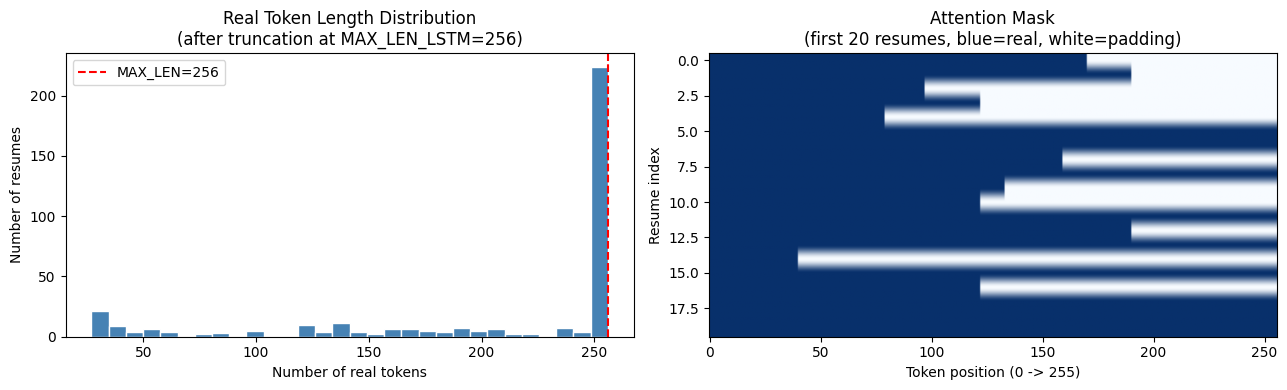

Resumes truncated (hit MAX_LEN=256): 223 / 220


In [52]:
# Inspect padding for a short vs long resume 
import matplotlib.pyplot as plt

real_lengths = [int(m.sum()) for m in masks]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution of real (non-padded) lengths
axes[0].hist(real_lengths, bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(MAX_LEN_LSTM, color='red', linestyle='--', label=f'MAX_LEN={MAX_LEN_LSTM}')
axes[0].set_title("Real Token Length Distribution\n(after truncation at MAX_LEN_LSTM=256)")
axes[0].set_xlabel("Number of real tokens")
axes[0].set_ylabel("Number of resumes")
axes[0].legend()

# Attention mask heatmap for first 20 resumes
axes[1].imshow(masks[:20], aspect='auto', cmap='Blues', vmin=0, vmax=1)
axes[1].set_title("Attention Mask\n(first 20 resumes, blue=real, white=padding)")
axes[1].set_xlabel("Token position (0 -> 255)")
axes[1].set_ylabel("Resume index")

plt.tight_layout()
plt.show()

truncated = sum(1 for l in real_lengths if l == MAX_LEN_LSTM)
print(f"Resumes truncated (hit MAX_LEN={MAX_LEN_LSTM}): {truncated} / {len(processed)}")

In [53]:
# Overlapping Chunks (BERT / DistilBERT)
# Max 512 sub-tokens per BERT call, long resumes are split with stride
# so each token appears in ≥2 chunks → context is never fully lost.

MAX_LEN_BERT = 512
STRIDE       = 128    # overlap between consecutive chunks


def sliding_window_chunks(
    token_ids      : list[int],
    label_ids      : list[int],
    max_len        : int  = MAX_LEN_BERT,
    stride         : int  = STRIDE,
    pad_token_id   : int  = 0,
    pad_label_id   : int  = 0,
) -> list[dict]:
    """
    Split a long sequence into overlapping fixed-length chunks.

    Parameters
    ----------
    max_len : maximum tokens per chunk (512 for BERT)
    stride  : step size between chunk starts (overlap = max_len - stride)

    Returns
    -------
    List of dicts, each with:
        token_ids, label_ids, attention_mask, chunk_start, chunk_end
    """
    chunks = []
    seq_len = len(token_ids)

    if seq_len == 0:
        return chunks

    # Generate chunk start positions
    starts = list(range(0, max(1, seq_len - max_len + 1), stride))
    if not starts or starts[-1] + max_len < seq_len:
        starts.append(max(0, seq_len - max_len))   # ensure last chunk covers end

    seen_starts = set()
    for start in starts:
        if start in seen_starts:
            continue
        seen_starts.add(start)
        end = start + max_len

        chunk_toks = token_ids[start:end]
        chunk_labs = label_ids[start:end]
        real_len = len(chunk_toks)
        pad_len = max_len - real_len

        attention_mask = [1] * real_len + [0] * pad_len
        chunk_toks = chunk_toks + [pad_token_id] * pad_len
        chunk_labs = chunk_labs + [pad_label_id] * pad_len

        chunks.append({
            'token_ids'      : chunk_toks,
            'label_ids'      : chunk_labs,
            'attention_mask' : attention_mask,
            'chunk_start'    : start,
            'chunk_end'      : start + real_len,
        })

    return chunks


# Build BERT dataset with chunking
bert_dataset = []
chunk_counts = []

for resume_id, p in enumerate(processed):
    bio_seq = p['sub_bio_norm']     # sub-word BIO for BERT
    tok_ids, lbl_ids = encode_sequence(bio_seq, token2id, label2id, UNK_ID)
    chunks = sliding_window_chunks(
        tok_ids, lbl_ids,
        max_len=MAX_LEN_BERT,
        stride=STRIDE,
        pad_token_id=PAD_ID,
        pad_label_id=PAD_LABEL_ID
    )
    chunk_counts.append(len(chunks))
    for chunk in chunks:
        chunk['resume_id'] = resume_id
        bert_dataset.append(chunk)

print(f"Total BERT chunks produced : {len(bert_dataset)}")
print(f"Resumes with >1 chunk      : {sum(1 for c in chunk_counts if c > 1)}")
print(f"Max chunks for one resume  : {max(chunk_counts)}")
print(f"Mean chunks per resume     : {sum(chunk_counts)/len(chunk_counts):.2f}")
print()

# Show chunking detail for the longest resume
longest_id = chunk_counts.index(max(chunk_counts))
bio_seq = processed[longest_id]['sub_bio_norm']
tok_ids, lbl_ids = encode_sequence(bio_seq, token2id, label2id, UNK_ID)
demo_chunks = sliding_window_chunks(tok_ids, lbl_ids)

print(f"Resume {longest_id} — length: {len(tok_ids)} sub-tokens -> {len(demo_chunks)} chunks")
print(f"(MAX_LEN_BERT={MAX_LEN_BERT}, STRIDE={STRIDE}, overlap={MAX_LEN_BERT - STRIDE})")
print()
print(f"{'Chunk':>6}  {'Start':>7}  {'End':>7}  {'Real tokens':>12}  {'Padding':>9}")
print("=" * 55)
for i, ch in enumerate(demo_chunks):
    real = sum(ch['attention_mask'])
    pad = MAX_LEN_BERT - real
    print(f"{i:>6}  {ch['chunk_start']:>7}  {ch['chunk_end']:>7}  {real:>12}  {pad:>9}")

Total BERT chunks produced : 535
Resumes with >1 chunk      : 81
Max chunks for one resume  : 20
Mean chunks per resume     : 2.43

Resume 101 — length: 2822 sub-tokens -> 20 chunks
(MAX_LEN_BERT=512, STRIDE=128, overlap=384)

 Chunk    Start      End   Real tokens    Padding
     0        0      512           512          0
     1      128      640           512          0
     2      256      768           512          0
     3      384      896           512          0
     4      512     1024           512          0
     5      640     1152           512          0
     6      768     1280           512          0
     7      896     1408           512          0
     8     1024     1536           512          0
     9     1152     1664           512          0
    10     1280     1792           512          0
    11     1408     1920           512          0
    12     1536     2048           512          0
    13     1664     2176           512          0
    14     1792     230

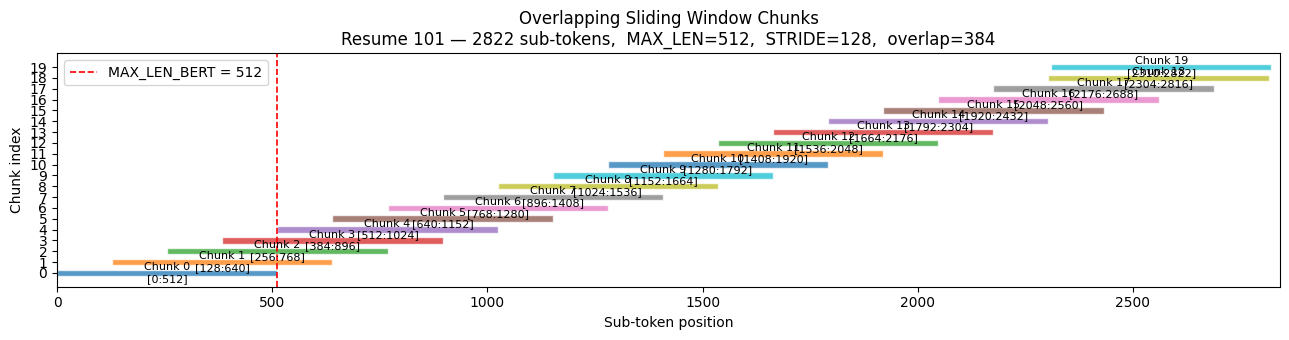

In [54]:
# Visualise: chunk overlap diagram for a long resume 
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(13, 3.5))

colors  = plt.cm.tab10.colors
seq_len = len(tok_ids)

for i, ch in enumerate(demo_chunks):
    start = ch['chunk_start']
    end = ch['chunk_end']
    color = colors[i % len(colors)]
    ax.barh(i, end - start, left=start, height=0.6, color=color, alpha=0.75, edgecolor='white')
    ax.text((start + end) / 2, i, f"Chunk {i}\n[{start}:{end}]", ha='center', va='center', fontsize=8, color='black')

ax.axvline(MAX_LEN_BERT, color='red', linestyle='--', linewidth=1.2, label=f"MAX_LEN_BERT = {MAX_LEN_BERT}")
ax.set_xlim(0, seq_len + 20)
ax.set_xlabel("Sub-token position")
ax.set_ylabel("Chunk index")
ax.set_title(
    f"Overlapping Sliding Window Chunks\n"
    f"Resume {longest_id} — {seq_len} sub-tokens,  "
    f"MAX_LEN={MAX_LEN_BERT},  STRIDE={STRIDE},  overlap={MAX_LEN_BERT - STRIDE}"
)
ax.set_yticks(range(len(demo_chunks)))
ax.legend()
plt.tight_layout()
plt.show()

### Saving Data

In [55]:
import pickle
import json as _json
from pathlib import Path

save_dir  = Path('../datasets/processed_data')
split_dir = Path('../datasets/split_data')
save_dir.mkdir(exist_ok=True)
split_dir.mkdir(exist_ok=True)

# processed BIO sequences
with open(save_dir / 'processed.pkl', 'wb') as f:
    pickle.dump(processed, f)

# vocabularies (dibangun dari train only — no leakage)
vocabs = {
    'token2id'        : token2id,
    'id2token'        : id2token,
    'label2id'        : label2id,
    'id2label'        : id2label,
    'char2id'         : char2id,
    'id2char'         : id2char,
    'PAD_ID'          : PAD_ID,
    'UNK_ID'          : UNK_ID,
    'PAD_TOKEN'       : PAD_TOKEN,
    'UNK_TOKEN'       : UNK_TOKEN,
    'PAD_LABEL_ID'    : PAD_LABEL_ID,
    'Entity_labels'   : Entity_labels,
    'Non_lemma_label' : list(Non_lemma_label),
    'EMBED_DIM'       : EMBED_DIM,
    'MAX_LEN_LSTM'    : MAX_LEN_LSTM,
    'MAX_LEN_BERT'    : MAX_LEN_BERT,
    'STRIDE'          : STRIDE,
}
with open(save_dir / 'vocabs.pkl', 'wb') as f:
    pickle.dump(vocabs, f)

# CRF/HMM splits
with open(save_dir / 'crf_train.pkl', 'wb') as f: pickle.dump(crf_train, f)
with open(save_dir / 'crf_val.pkl',   'wb') as f: pickle.dump(crf_val, f)
with open(save_dir / 'crf_test.pkl',  'wb') as f: pickle.dump(crf_test, f)

# numpy arrays — full dataset
np.save(save_dir / 'X_tokens.npy',         X_tokens)
np.save(save_dir / 'X_chars.npy',          X_chars)
np.save(save_dir / 'Y_labels.npy',         Y_labels)
np.save(save_dir / 'masks.npy',            masks)
np.save(save_dir / 'embedding_matrix.npy', embedding_matrix)

# per-split arrays (BiLSTM)
np.save(save_dir / 'X_tokens_train.npy',  X_tokens_train)
np.save(save_dir / 'X_chars_train.npy',   X_chars_train)
np.save(save_dir / 'Y_labels_train.npy',  Y_labels_train)
np.save(save_dir / 'masks_train.npy',     masks_train)

np.save(save_dir / 'X_tokens_val.npy',    X_tokens_val)
np.save(save_dir / 'X_chars_val.npy',     X_chars_val)
np.save(save_dir / 'Y_labels_val.npy',    Y_labels_val)
np.save(save_dir / 'masks_val.npy',       masks_val)

np.save(save_dir / 'X_tokens_test.npy',   X_tokens_test)
np.save(save_dir / 'X_chars_test.npy',    X_chars_test)
np.save(save_dir / 'Y_labels_test.npy',   Y_labels_test)
np.save(save_dir / 'masks_test.npy',      masks_test)

# split indices
with open(split_dir / 'split_indices.json', 'w') as f:
    _json.dump({
        'idx_train': idx_train,
        'idx_val': idx_val,
        'idx_test': idx_test,
        'idx_train_balanced': idx_train_balanced,
    }, f)

print("Saved:")
for ff in sorted(save_dir.iterdir()):
    print(f"  {ff.name:<35} {ff.stat().st_size/1024:.1f} KB")
print(f"\n  split_indices.json -> train={len(idx_train)} / val={len(idx_val)} / test={len(idx_test)} / balanced_train={len(idx_train_balanced)}")

Saved:
  crf_test.pkl                        2361.8 KB
  crf_train.pkl                       9080.8 KB
  crf_val.pkl                         2068.3 KB
  embedding_matrix.npy                3958.7 KB
  hmm_model.pkl                       1216.3 KB
  masks.npy                           366.1 KB
  masks_test.npy                      33.1 KB
  masks_train.npy                     300.1 KB
  masks_val.npy                       33.1 KB
  processed.pkl                       6811.7 KB
  vocabs.pkl                          73.2 KB
  X_chars.npy                         7320.1 KB
  X_chars_test.npy                    660.1 KB
  X_chars_train.npy                   6000.1 KB
  X_chars_val.npy                     660.1 KB
  X_tokens.npy                        366.1 KB
  X_tokens_test.npy                   33.1 KB
  X_tokens_train.npy                  300.1 KB
  X_tokens_val.npy                    33.1 KB
  Y_labels.npy                        366.1 KB
  Y_labels_test.npy                   33.1 KB
  Y_